# Notebook 07 — Engenharia de atributos e baseline


In [2]:
# Baseline de regressão para o teor de argila
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_DIR = Path(r"C:\Users\PC\Desktop\RESET")
CANDIDATE_FILES = [
    "raw_nir_data_Saturin.csv",
    "raw_mir_data_Saturin.csv",
    "raw_nir_data_saturin.csv",
    "raw_mir_data_saturin.csv",
]


def resolve_dataset():
    for file_name in CANDIDATE_FILES:
        file_path = DATA_DIR / file_name
        if file_path.exists():
            return file_path
    raise FileNotFoundError(f"Arquivo espectral não encontrado em {DATA_DIR}")


def read_csv_robust(file_path):
    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            return pd.read_csv(file_path, encoding=encoding, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Não foi possível decodificar {file_path.name}")


df = read_csv_robust(resolve_dataset())
df = df.drop(columns=[column for column in df.columns if str(column).lower().startswith("unnamed")], errors="ignore")

# Detecta as bandas espectrais por prefixo wl_ ou pelo nome numérico da banda.
spectral_columns = [column for column in df.columns if str(column).lower().startswith("wl_")]
if not spectral_columns:
    for column in df.columns:
        try:
            wavelength = float(str(column).strip().replace(",", "."))
        except (TypeError, ValueError):
            continue
        if 300 <= wavelength <= 4000:
            spectral_columns.append(column)

if not spectral_columns:
    raise ValueError("Nenhuma coluna espectral foi encontrada no arquivo carregado.")

# Localiza a variável de argila sem depender de maiúsculas ou minúsculas.
clay_aliases = {"clay", "clay_gkg", "argila", "argila_gkg"}
clay_column = next(
    (
        column for column in df.columns
        if str(column).strip().lower() in clay_aliases
    ),
    None,
)
if clay_column is None:
    raise ValueError(
        "Coluna de argila não encontrada. Colunas disponíveis: "
        + ", ".join(map(str, df.columns[:20]))
    )

X = df[spectral_columns].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df[clay_column], errors="coerce")
valid_rows = X.notna().any(axis=1) & y.notna()
X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()
X = X.fillna(X.median()).fillna(0.0)

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)

base = DummyRegressor(strategy="mean")
base.fit(Xtr, ytr)
predictions = base.predict(Xte)

mae = mean_absolute_error(yte, predictions)
rmse = np.sqrt(mean_squared_error(yte, predictions))
r2 = r2_score(yte, predictions)

print(f"Dataset: {resolve_dataset().name}")
print(f"Amostras válidas: {len(y)}")
print(f"Bandas espectrais: {X.shape[1]}")
print(f"Variável alvo: {clay_column}")
print(f"Baseline MAE: {mae:.4f}")
print(f"Baseline RMSE: {rmse:.4f}")
print(f"Baseline R2: {r2:.4f}")


Dataset: raw_nir_data_Saturin.csv
Amostras válidas: 29249
Bandas espectrais: 2151
Variável alvo: Clay_gkg
Baseline MAE: 126.7221
Baseline RMSE: 162.8870
Baseline R2: -0.0000


Amostras: 29249 | Treino: 17549 | Validação: 5850 | Teste: 5850
Atributos compactos: 13 | Bandas no espectro completo: 2151

Comparação na validação:


,model,MAE_validacao,RMSE_validacao,R2_validacao
0,PLS + espectro completo,82.7883,111.9666,0.5088
1,Extra Trees + atributos,87.9376,117.7677,0.4566
2,Ridge + atributos,103.3843,136.2279,0.2729
3,Baseline (média),124.3514,159.7635,-0.0000


Melhor modelo selecionado: PLS + espectro completo

Métricas finais no teste intocado:
MAE_teste: 84.9566
RMSE_teste: 115.1219
R2_teste: 0.4919

Primeiras previsões da base completa:


,observed_clay_gkg,predicted_clay_gkg,residual_gkg
0,90.0,258.084983,-168.084983
1,290.0,351.208306,-61.208306
2,450.0,427.152163,22.847837
3,550.0,449.958661,100.041339
4,530.0,441.892770,88.107230


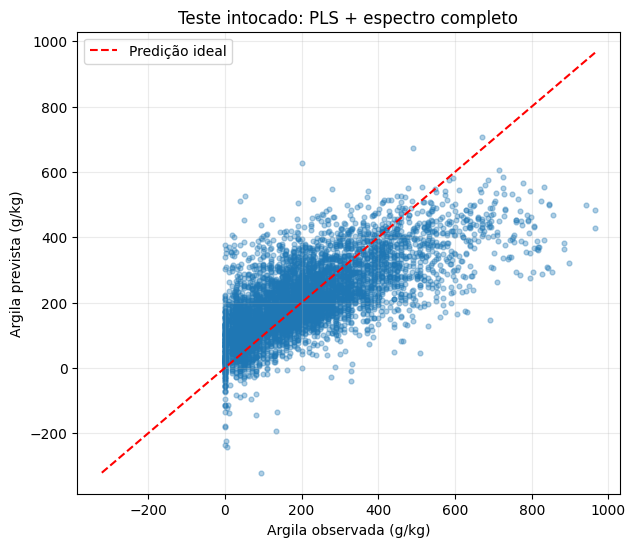

In [5]:
# Seleção do melhor modelo e previsão para a base completa
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Usa a base X/y carregada na célula anterior.
if "X" not in globals() or "y" not in globals():
    raise NameError("Execute primeiro a célula de carregamento da base espectral.")

spectral_values = X.to_numpy(dtype=float)
try:
    wavelength_values = np.array(
        [float(str(column).replace("wl_", "").replace(",", ".")) for column in X.columns],
        dtype=float,
    )
except ValueError:
    wavelength_values = np.arange(spectral_values.shape[1], dtype=float)

band_order = np.argsort(wavelength_values)
wavelength_values = wavelength_values[band_order]
spectral_values = spectral_values[:, band_order]

# Atributos compactos para modelos que não precisam de todas as 2.151 bandas.
def build_spectral_features(spectra, wavelengths):
    derivative = np.gradient(spectra, wavelengths, axis=1)
    centered = spectra - spectra.mean(axis=1, keepdims=True)
    return pd.DataFrame({
        "spectral_mean": spectra.mean(axis=1),
        "spectral_std": spectra.std(axis=1),
        "spectral_min": spectra.min(axis=1),
        "spectral_max": spectra.max(axis=1),
        "spectral_range": spectra.max(axis=1) - spectra.min(axis=1),
        "spectral_median": np.median(spectra, axis=1),
        "spectral_q25": np.quantile(spectra, 0.25, axis=1),
        "spectral_q75": np.quantile(spectra, 0.75, axis=1),
        "derivative_mean": derivative.mean(axis=1),
        "derivative_std": derivative.std(axis=1),
        "derivative_abs_mean": np.abs(derivative).mean(axis=1),
        "centered_energy": np.mean(centered ** 2, axis=1),
        "spectral_area": np.trapezoid(spectra, wavelengths, axis=1),
    })


X_features = build_spectral_features(spectral_values, wavelength_values)
y_values = y.to_numpy(dtype=float)
all_indices = np.arange(len(y_values))

# Mantém um teste final intocado; o modelo é escolhido apenas na validação.
development_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42,
)
train_indices, validation_indices = train_test_split(
    development_indices,
    test_size=0.25,
    random_state=42,
)

X_train_features = X_features.iloc[train_indices]
X_validation_features = X_features.iloc[validation_indices]
X_development_features = X_features.iloc[development_indices]
X_test_features = X_features.iloc[test_indices]

X_train_spectral = spectral_values[train_indices]
X_validation_spectral = spectral_values[validation_indices]
X_development_spectral = spectral_values[development_indices]
X_test_spectral = spectral_values[test_indices]
y_train = y_values[train_indices]
y_validation = y_values[validation_indices]
y_development = y_values[development_indices]
y_test = y_values[test_indices]

# Modelos candidatos: baseline, atributos compactos e espectro completo.
def make_models():
    return {
        "Baseline (média)": DummyRegressor(strategy="mean"),
        "Ridge + atributos": Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=10.0)),
        ]),
        "Extra Trees + atributos": ExtraTreesRegressor(
            n_estimators=150,
            min_samples_leaf=3,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1,
        ),
        "PLS + espectro completo": Pipeline([
            ("scaler", StandardScaler()),
            ("pls", PLSRegression(n_components=15, scale=False)),
        ]),
    }


def fit_and_predict(model_name, model, fit_features, fit_spectral, fit_target, predict_features, predict_spectral):
    if "espectro completo" in model_name:
        model.fit(fit_spectral, fit_target)
        return model.predict(predict_spectral).ravel()
    model.fit(fit_features, fit_target)
    return model.predict(predict_features).ravel()


validation_results = []
for model_name, model in make_models().items():
    validation_prediction = fit_and_predict(
        model_name,
        model,
        X_train_features,
        X_train_spectral,
        y_train,
        X_validation_features,
        X_validation_spectral,
    )
    validation_results.append({
        "model": model_name,
        "MAE_validacao": mean_absolute_error(y_validation, validation_prediction),
        "RMSE_validacao": np.sqrt(mean_squared_error(y_validation, validation_prediction)),
        "R2_validacao": r2_score(y_validation, validation_prediction),
    })

validation_comparison = pd.DataFrame(validation_results).sort_values("RMSE_validacao").reset_index(drop=True)
best_model_name = validation_comparison.loc[0, "model"]

# Reajusta somente o modelo vencedor usando treino + validação.
best_model = make_models()[best_model_name]
if "espectro completo" in best_model_name:
    best_model.fit(X_development_spectral, y_development)
    test_prediction = best_model.predict(X_test_spectral).ravel()
    full_prediction = best_model.predict(spectral_values).ravel()
else:
    best_model.fit(X_development_features, y_development)
    test_prediction = best_model.predict(X_test_features).ravel()
    full_prediction = best_model.predict(X_features).ravel()

final_metrics = {
    "MAE_teste": mean_absolute_error(y_test, test_prediction),
    "RMSE_teste": np.sqrt(mean_squared_error(y_test, test_prediction)),
    "R2_teste": r2_score(y_test, test_prediction),
}

# Predições alinhadas com a base original e prontas para exportação.
prediction_results = pd.DataFrame({
    "observed_clay_gkg": y_values,
    "predicted_clay_gkg": full_prediction,
})
prediction_results["residual_gkg"] = (
    prediction_results["observed_clay_gkg"]
    - prediction_results["predicted_clay_gkg"]
)

print(f"Amostras: {len(y_values)} | Treino: {len(train_indices)} | Validação: {len(validation_indices)} | Teste: {len(test_indices)}")
print(f"Atributos compactos: {X_features.shape[1]} | Bandas no espectro completo: {spectral_values.shape[1]}")
print("\nComparação na validação:")
display(validation_comparison.round(4))
print(f"Melhor modelo selecionado: {best_model_name}")
print("\nMétricas finais no teste intocado:")
for metric_name, metric_value in final_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")
print("\nPrimeiras previsões da base completa:")
display(prediction_results.head())

plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_prediction, alpha=0.35, s=12)
plot_min = min(y_test.min(), test_prediction.min())
plot_max = max(y_test.max(), test_prediction.max())
plt.plot([plot_min, plot_max], [plot_min, plot_max], "r--", label="Predição ideal")
plt.xlabel("Argila observada (g/kg)")
plt.ylabel("Argila prevista (g/kg)")
plt.title(f"Teste intocado: {best_model_name}")
plt.legend()
plt.grid(alpha=0.25)
plt.show()
